In [2]:
import math
import snappy
import pandas as pd
from khovanov import *
from knot_graphs import *

In [3]:
def draw_movie(M):
    for l in M.links:
        draw_adjacency_graph(l)
        plt.show()

# Finding Band moves from $T(4,n)$ (small $n$) to the unknot $\mathcal{U}$

### TODO
- For $T(4,5)$ try to find 2 band moves to the unknot ($\gamma_4(T(4,5)) = 2$ so we need exactly two bands) and compute their normal euler number and upsilon to place them in the wedge plot
- Fix $T(4,n)$ for small $n$ and do non-pinch moves + have snappy idenfity resulting knots
    - Check $e=w-w'$ and ignore $e=0$ (these are orientable band moves)

In [4]:
T45 = snappy.Link('T(4,5)')

In [5]:
G = adjacency_graph(T45)
G.nodes

NodeView(((0, 0), (0, 1), (0, 2), (1, 0), (1, 1), (1, 2), (2, 0), (2, 1), (2, 2), (3, 0), (3, 1), (3, 2), (4, 0), (4, 1), (4, 2)))

['arc3,rad=0', 'arc3,rad=0', 'arc3,rad=0', 'arc3,rad=0', 'arc3,rad=0', 'arc3,rad=0', 'arc3,rad=0', 'arc3,rad=0', 'arc3,rad=0', 'arc3,rad=0', 'arc3,rad=0', 'arc3,rad=0', 'arc3,rad=0', 'arc3,rad=0', 'arc3,rad=0', 'arc3,rad=0', 'arc3,rad=0', 'arc3,rad=0', 'arc3,rad=0', 'arc3,rad=0', 'arc3,rad=0', 'arc3,rad=0', 'arc3,rad=0', 'arc3,rad=0', 'arc3,rad=0', 'arc3,rad=0', 'arc3,rad=0', 'arc3,rad=0', 'arc3,rad=0', 'arc3,rad=0']
{((0, 0), (4, 1), 0): 0, ((0, 0), (4, 0), 0): 0, ((0, 1), (4, 2), 0): 0, ((0, 1), (0, 0), 0): 0, ((0, 2), (4, 2), 0): 0, ((0, 2), (0, 1), 0): 0, ((1, 0), (0, 1), 0): 0, ((1, 0), (0, 0), 0): 0, ((1, 1), (0, 2), 0): 0, ((1, 1), (1, 0), 0): 0, ((1, 2), (0, 2), 0): 0, ((1, 2), (1, 1), 0): 0, ((2, 0), (1, 1), 0): 0, ((2, 0), (1, 0), 0): 0, ((2, 1), (1, 2), 0): 0, ((2, 1), (2, 0), 0): 0, ((2, 2), (1, 2), 0): 0, ((2, 2), (2, 1), 0): 0, ((3, 0), (2, 1), 0): 0, ((3, 0), (2, 0), 0): 0, ((3, 1), (2, 2), 0): 0, ((3, 1), (3, 0), 0): 0, ((3, 2), (2, 2), 0): 0, ((3, 2), (3, 1), 0): 0, ((

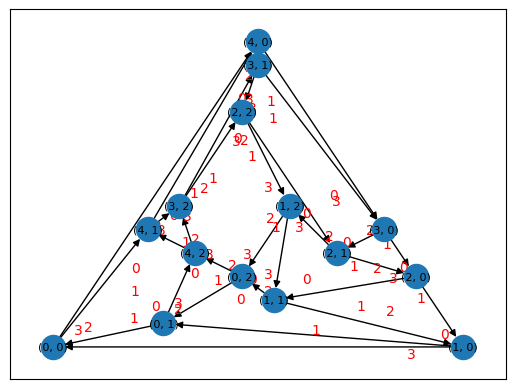

In [6]:
draw_adjacency_graph(T45, rad_increment=0.2)

In [7]:
T45.view()

In [8]:
%gui tk

## 

Lemma 2.1. ([Sabloff](https://arxiv.org/pdf/2206.11200))

The result of applying a pinch move to $T(p,q)$ is the torus knot $T(p-2t,q-2u)$ where
$$
\begin{cases}
t \equiv -q^{-1}\bmod p, \\
u \equiv p^{-1}\bmod q.
\end{cases}
$$
Let's see what the resulting knots look like.

In [9]:
def pinch_result(p,q):
    t = (pow(q, -1, p) * -1) % p
    u = pow(p, -1, q)
    if t < 0:
        t += p

    p_prime = p - 2 * t
    q_prime = q - 2 * u

    # "the signs of p − 2t and q − 2u agree when both quantities are nonzero"
    if p_prime < 0:
        return -p_prime, -q_prime
    else:
        return p_prime, q_prime

In [10]:
inputs = []
outputs = []
for p in range(5, 20):
    if math.gcd(p,4) != 1:
        continue

    p_prime, q_prime = pinch_result(p, 4)
    inputs.append(f'T({p},4)')
    outputs.append(f'T({p_prime},{q_prime})')
        
pd.DataFrame(zip(inputs, outputs), columns=['Knot', 'Result after pinch move'])

,Knot,Result after pinch move
0,"T(5,4)","T(3,2)"
1,"T(7,4)","T(3,2)"
2,"T(9,4)","T(5,2)"
3,"T(11,4)","T(5,2)"
4,"T(13,4)","T(7,2)"
5,"T(15,4)","T(7,2)"
6,"T(17,4)","T(9,2)"
7,"T(19,4)","T(9,2)"


We can use this to compute the sequence of knots in the cobordism taking each $T(p,q)$ to the unknot $\mathcal{U}$.

Theorem 2.6. ([Jabuka and Van Cott](https://arxiv.org/pdf/1809.01779))
Assuming that $p,q\in\mathbb{Z}_+$ with $\text{gcd}(p,q)=1$, $q$ odd, and $p>q$ if $p$ is also odd, then $T(p,q)$ reduces to the unknot via the following sequence.

$$
T(p,q) = T(p_n,q_n)
\xrightarrow{\epsilon_n}
T(p_{n-1},q_{n-1}
\xrightarrow{\epsilon_{n-1}}
\cdots
\xrightarrow{\epsilon_{1}}
T(p_0,q_0)=\mathcal{U}
$$

Each $p_{i},q_{i}$ is determined by Lemma 2.1 with $p=p_{i+1}, q=q_{i+1}$.

In [11]:
def pinch_knot_sequence(p,q):
    knots = [(p,q)]
    # q_0 should equal 1
    while knots[-1][1] > 1:
        knots.append(pinch_result(knots[-1][0], knots[-1][1]))
    return knots

In [12]:
pinch_knot_sequence(6,5)

[(6, 5), (4, 3), (2, 1)]

Lemma 2.3. (Sabloff)
If $T(p,q)$ is transformed to $T(p_0,1)$ in the construction of the pinch surface $F(p,q)$ then
$$
e(F(p,q)) = p_0 - pq.
$$
So despite our general normal euler number implementation being broken, we can compute $e$ for pinch surfaces $F(p,q)$ as follows:

In [13]:
# assumes q odd 
def pinch_surface_euler(p,q):
    knots = pinch_knot_sequence(p,q)
    p_0 = knots[-1][0]
    return p_0 - p * q

In [14]:
q = 5 # q must be odd
knot_seqs = []
es = []
invalids = []
for p in range(2, 30):
    if math.gcd(p,q) != 1:
        continue

    knots = []
    e = 9999
    if p % 2 == 0:
        knots = pinch_knot_sequence(p,q)
        e = pinch_surface_euler(p,q)
    else:
        if p < q:
            knots = pinch_knot_sequence(q,p)
            e = pinch_surface_euler(q,p)
        else: # p > q
            knots = pinch_knot_sequence(p,q)
            e = pinch_surface_euler(p,q)
            
    knot_seq = ' --> '.join([f'T({p},{q})' for p,q in knots])
    knot_seqs.append(knot_seq)
    es.append(e)
    if knots[-1][1] == 1:
        invalids.append(' ')
    else:
        invalids.append('✗')

pd.DataFrame(zip(knot_seqs, es, invalids), columns=[f'T(p,{q}) pinch cobordism', 'e(F(p,q))', 'invalid sequence?'])

,"T(p,5) pinch cobordism","e(F(p,q))",invalid sequence?
0,"T(2,5) --> T(0,-1)",-10,✗
1,"T(5,3) --> T(1,1)",-14,
2,"T(4,5) --> T(2,3) --> T(0,-1)",-20,✗
3,"T(6,5) --> T(4,3) --> T(2,1)",-28,
4,"T(7,5) --> T(1,1)",-34,
5,"T(8,5) --> T(2,1)",-38,
6,"T(9,5) --> T(5,3) --> T(1,1)",-44,
7,"T(11,5) --> T(7,3) --> T(3,1)",-52,
8,"T(12,5) --> T(2,1)",-58,
9,"T(13,5) --> T(3,1)",-62,


### TODO - fix/ignore(?) cobordisms ending in $T(p_0, -1)$

### TODO - do we need `extends_to_link=True`?
"If the flag “extends_to_link” is True, requires that the isometry sends meridians to meridians. If the input manifold is closed this will result in no matches being returned."

### TODO - do we need `with_hyperbolic_structure=True`?

In [14]:
def find_bands(K, cutoff=100):
    if cutoff is None:
        import sys
        cutoff = sys.maxint
    
    num_crossings = len(K.crossings)

    snappy_K = snappy.Link(K.PD_code())
    writhe = snappy_K.writhe()

    c0s = []
    c1s = []
    s0s = []
    s1s = []
    es = []
    twists = []
    results = []
    
    i = 0
    cutoff_reached = False
    for c0 in range(num_crossings):
        if cutoff_reached: break
        for c1 in range(num_crossings):
            if cutoff_reached: break
            for s0 in range(4):
                if cutoff_reached: break
                for s1 in range(4):
                    if cutoff_reached: break
                    if c0 == c1 and s0 == s1: continue
                    for twist in [-1, 0, 1]:
                        if i >= cutoff:
                            cutoff_reached = True
                        if cutoff_reached: break

                        twists.append(twist)
                        c0s.append(c0)
                        c1s.append(c1)
                        s0s.append(s0)
                        s1s.append(s1)
                        
                        S = Cobordism(K)
                        i += 1
                        try:
                            S.band_move(twist, (c0, s0), (c1, s1))
                            #S.finish()
    
                            K_prime = S.links[-1]
                            snappy_K_prime = snappy.Link(K_prime.PD_code())
                            
                            writhe_prime = snappy_K_prime.writhe()
                            normal_euler = writhe_prime - writhe
                            es.append(normal_euler)
    
                            complement = snappy_K_prime.exterior()
                            result = complement.identify(extends_to_link=True)
                            results.append(result)
                        except:
                            continue

    return pd.DataFrame(zip(twists, c0s, s0s, c1s, s1s, es, results),
                        columns=['twist', 'c0', 's0', 'c1', 's1', 'e', 'resulting knot'])

### TODO - identify when `S.finish()` fails vs. when snappy cannot identify `K_prime`

### TODO - look into hosting this notebook on NCSA cluster for longer computation times/memory
[LINK](jupyter.ncsa.illinois.edu)

In [15]:
T45_link = Link(T45.PD_code())
df = find_bands(T45_link, cutoff=100)
df

Your new Plink window needs an event loop to become visible.
Type "%gui tk" below (without the quotes) to start one.



,twist,c0,s0,c1,s1,e,resulting knot
0,-1,0,0,0,1,-13,[]
1,0,0,0,0,1,-12,[]
2,1,0,0,0,1,-11,"[v0600(0,0), K7_25(0,0)]"
3,-1,0,0,0,2,-14,[]
4,0,0,0,0,2,-12,[]
5,1,0,0,0,2,-15,[]
6,-1,0,0,0,3,-14,[]
7,0,0,0,0,3,-13,[]
8,1,0,0,0,3,-14,[]
9,-1,0,1,0,0,-13,[]


### TODO - euler number should be even

### TODO - verify $e(F) \equiv 2 \chi(F) \bmod 4$

Cobordism package README.md: "C.chi() returns the Euler characteristic of the cobordism."

### TODO - try other twist numbers for band moves

### TODO - try to send Cobordism `Link`'s to snappy via crossing structure directly in order to (hopefully) fix normal euler number bug

In [16]:
T45.writhe()

15

In [17]:
S = Cobordism(T45_link)
S.band_move(1, (0,0), (0,1))
#S.finish()

In [18]:
K = snappy.Link(S.links[-1].PD_code())
K.writhe()

4

In [19]:
K.writhe() - T45.writhe()

-11

In [20]:
K.view()

In [21]:
K.exterior().identify()

[v0600(0,0), K7_25(0,0)]

### TODO - we know that $F(p,q)$ gives us the minimum $b_1$ for a vertical slice of the wedge region determined by $p,q$. We want to find other band moves from $T(p,q)$ that give us the same $b_1$.

Geometrically, we want to find other realizable points on the horizontal line.
They necessarily have to be realized by non-pinch moves.

We have the width of the signature bound given by:
$$
\left| \sigma - \frac{e}{2} \right| \le b_1
$$
for fixed $b_1\in\mathbb{N}$